Sel 1 — Mount Google Drive & Install Library

In [8]:
from google.colab import drive
drive.mount('/content/drive')

!pip install albumentations tqdm opencv-python scikit-learn matplotlib -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Sel 2 — Import Library

In [9]:
import os
import shutil
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path
import albumentations as A
from tqdm import tqdm
from collections import Counter

Sel 3 — Konfigurasi Path & Parameter

In [10]:
BASE_DIR        = Path("/content/drive/MyDrive/Pothole_Classification_Project")
RAW_DIR         = BASE_DIR / "dataset/1_raw"
PROCESSED_DIR   = BASE_DIR / "dataset/2_processed"
TRAIN_DIR       = PROCESSED_DIR / "train"
TEST_DIR        = PROCESSED_DIR / "test"
OUTPUT_DIR      = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES         = ["berlubang", "mulus"]
IMG_SIZE        = (224, 224)
TEST_SPLIT      = 0.2
RANDOM_STATE    = 42
AUG_PER_IMAGE   = 10

for cls in CLASSES:
    (TRAIN_DIR / cls).mkdir(parents=True, exist_ok=True)
    (TEST_DIR  / cls).mkdir(parents=True, exist_ok=True)

print("✅ Struktur folder siap.")
print(f"   RAW       → {RAW_DIR}")
print(f"   TRAIN     → {TRAIN_DIR}")
print(f"   TEST      → {TEST_DIR}")

✅ Struktur folder siap.
   RAW       → /content/drive/MyDrive/Pothole_Classification_Project/dataset/1_raw
   TRAIN     → /content/drive/MyDrive/Pothole_Classification_Project/dataset/2_processed/train
   TEST      → /content/drive/MyDrive/Pothole_Classification_Project/dataset/2_processed/test


Sel 4 — Verifikasi Dataset Mentah

In [11]:
print("📂 Pengecekan dataset mentah:\n")
for cls in CLASSES:
    files = list((RAW_DIR / cls).glob("*.[jp][pn]g")) + \
            list((RAW_DIR / cls).glob("*.jpeg"))
    print(f"  [{cls}] → {len(files)} gambar ditemukan")

📂 Pengecekan dataset mentah:

  [berlubang] → 175 gambar ditemukan
  [mulus] → 175 gambar ditemukan


Sel 5 — Reset Folder Processed

In [12]:
for split_dir in [TRAIN_DIR, TEST_DIR]:
    if split_dir.exists():
        shutil.rmtree(split_dir)
        print(f"🗑️  Dihapus: {split_dir}")

for cls in CLASSES:
    (TRAIN_DIR / cls).mkdir(parents=True, exist_ok=True)
    (TEST_DIR  / cls).mkdir(parents=True, exist_ok=True)

print("✅ Folder processed direset dan siap diisi ulang.")

🗑️  Dihapus: /content/drive/MyDrive/Pothole_Classification_Project/dataset/2_processed/train
🗑️  Dihapus: /content/drive/MyDrive/Pothole_Classification_Project/dataset/2_processed/test
✅ Folder processed direset dan siap diisi ulang.


Sel 6 — Split Train / Test

In [13]:
all_images, all_labels = [], []

for cls in CLASSES:
    paths = sorted((RAW_DIR / cls).glob("*.[jp][pn]g")) + \
            sorted((RAW_DIR / cls).glob("*.jpeg"))
    all_images.extend(paths)
    all_labels.extend([cls] * len(paths))

train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_images, all_labels,
    test_size    = TEST_SPLIT,
    stratify     = all_labels,
    random_state = RANDOM_STATE
)

print(f"📊 Hasil split:")
print(f"   Train : {len(train_paths)} gambar")
print(f"   Test  : {len(test_paths)}  gambar")

📊 Hasil split:
   Train : 280 gambar
   Test  : 70  gambar


Sel 7 — Visualisasi Distribusi Split Data

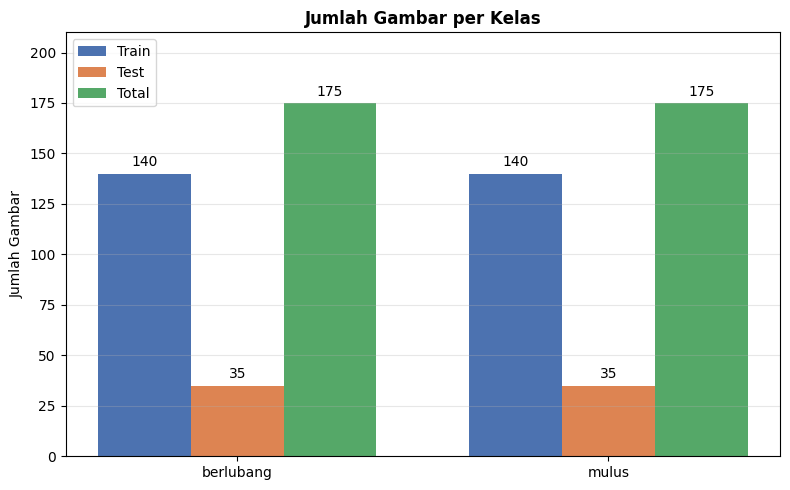

✅ Grafik distribusi split data disimpan ke outputs/

  Ringkasan:
  Kelas              Train     Test    Total
  ------------------------------------------
  berlubang            140       35      175
  mulus                140       35      175
  ------------------------------------------
  TOTAL                280       70      350


In [23]:
train_count = Counter(train_labels)
test_count  = Counter(test_labels)

categories  = CLASSES
train_vals  = [train_count[cls] for cls in categories]
test_vals   = [test_count[cls]  for cls in categories]
total_vals  = [train_count[cls] + test_count[cls] for cls in categories]

x     = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width, train_vals, width, label="Train", color="#4C72B0")
bars2 = ax.bar(x,         test_vals,  width, label="Test",  color="#DD8452")
bars3 = ax.bar(x + width, total_vals, width, label="Total", color="#55A868")

ax.bar_label(bars1, padding=3, fontsize=10)
ax.bar_label(bars2, padding=3, fontsize=10)
ax.bar_label(bars3, padding=3, fontsize=10)

ax.set_title("Jumlah Gambar per Kelas", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Jumlah Gambar")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(total_vals) * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribusi_split_data.png", dpi=150, bbox_inches="tight")
plt.show()

total_train = sum(train_vals)
total_test  = sum(test_vals)

print("✅ Grafik distribusi split data disimpan ke outputs/")
print(f"\n  Ringkasan:")
print(f"  {'Kelas':<15} {'Train':>8} {'Test':>8} {'Total':>8}")
print(f"  {'-'*42}")
for cls in categories:
    print(f"  {cls:<15} {train_count[cls]:>8} {test_count[cls]:>8} {train_count[cls]+test_count[cls]:>8}")
print(f"  {'-'*42}")
print(f"  {'TOTAL':<15} {total_train:>8} {total_test:>8} {total_train+total_test:>8}")

Sel 8 — Simpan Test Set (Tanpa Augmentasi)

In [15]:
def save_resized(src_path, dst_folder, size=IMG_SIZE):
    """Resize & simpan gambar tanpa augmentasi apapun."""
    img = cv2.imread(str(src_path))
    if img is None:
        print(f"⚠️  Gagal membaca: {src_path}")
        return
    img_resized = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    dst_path    = dst_folder / src_path.name
    cv2.imwrite(str(dst_path), img_resized)

print("💾 Menyimpan Test Set ...")
for path, label in tqdm(zip(test_paths, test_labels), total=len(test_paths)):
    save_resized(path, TEST_DIR / label)

print(f"✅ Test Set tersimpan → {TEST_DIR}")

💾 Menyimpan Test Set ...


100%|██████████| 70/70 [01:35<00:00,  1.37s/it]

✅ Test Set tersimpan → /content/drive/MyDrive/Pothole_Classification_Project/dataset/2_processed/test


Sel 9 — Definisi Pipeline Augmentasi

In [16]:
augment_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=25, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.GaussNoise(std_range=(0.02, 0.1), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.4),
    A.CLAHE(clip_limit=2.0, p=0.3),
])

Sel 10 — Augmentasi & Simpan Train Set

In [17]:
print(f"⚙️  Memulai augmentasi (×{AUG_PER_IMAGE} per gambar)...\n")

total_saved = {cls: 0 for cls in CLASSES}

for path, label in tqdm(zip(train_paths, train_labels), total=len(train_paths)):
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        continue
    img_bgr = cv2.resize(img_bgr, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    stem = path.stem

    out_orig = TRAIN_DIR / label / f"{stem}_aug000.jpg"
    cv2.imwrite(str(out_orig), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    total_saved[label] += 1

    for i in range(1, AUG_PER_IMAGE + 1):
        augmented = augment_pipeline(image=img_rgb)["image"]
        out_path  = TRAIN_DIR / label / f"{stem}_aug{i:03d}.jpg"
        cv2.imwrite(str(out_path), cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))
        total_saved[label] += 1

print("\n✅ Augmentasi selesai!")
for cls in CLASSES:
    print(f"   [{cls}] → {total_saved[cls]} gambar tersimpan di train/")

⚙️  Memulai augmentasi (×10 per gambar)...



100%|██████████| 280/280 [05:13<00:00,  1.12s/it]


✅ Augmentasi selesai!
   [berlubang] → 1540 gambar tersimpan di train/
   [mulus] → 1540 gambar tersimpan di train/


Sel 11 — Verifikasi Akhir

In [18]:
print("📋 Rekapitulasi dataset setelah preprocessing:\n")
for split, base_dir in [("TRAIN", TRAIN_DIR), ("TEST", TEST_DIR)]:
    print(f"  [{split}]")
    for cls in CLASSES:
        count = len(list((base_dir / cls).glob("*.jpg")))
        print(f"    {cls:>12} : {count} gambar")
    print()

📋 Rekapitulasi dataset setelah preprocessing:

  [TRAIN]
       berlubang : 1540 gambar
           mulus : 1540 gambar

  [TEST]
       berlubang : 35 gambar
           mulus : 35 gambar



Sel 12 — Visualisasi Sampel

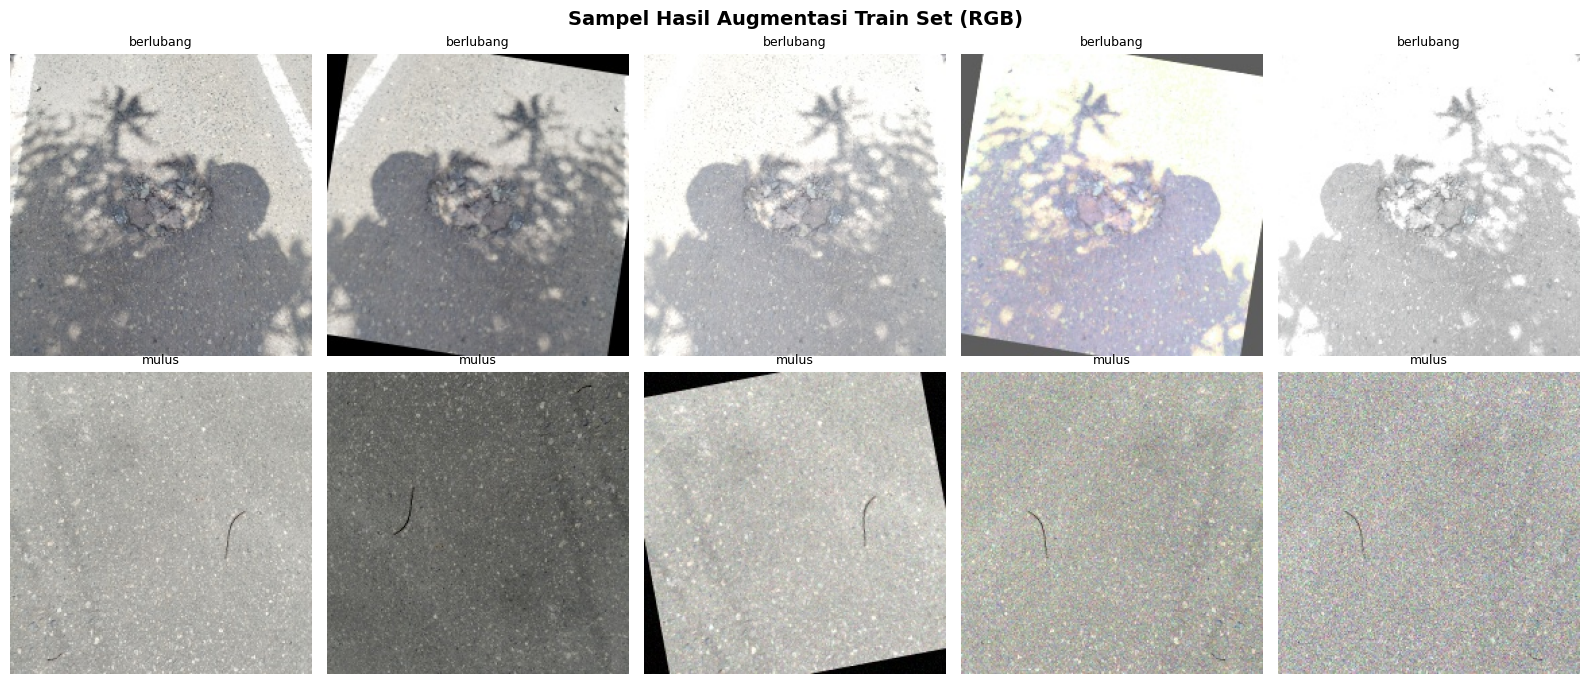

✅ Gambar sampel disimpan ke outputs/


In [19]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("Sampel Hasil Augmentasi Train Set (RGB)", fontsize=14, fontweight="bold")

for row, cls in enumerate(CLASSES):
    samples = list((TRAIN_DIR / cls).glob("*.jpg"))[:5]
    for col, img_path in enumerate(samples):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis("off")

plt.tight_layout()

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "sample_augmented_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gambar sampel disimpan ke outputs/")